<a href="https://colab.research.google.com/github/arsingla786/MLFromScratch/blob/main/Dropout_Layer(Overfitting_control).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##regression problem

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
X_train = np.linspace(-1, 1, 20)

In [ ]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  ,
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475,
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [ ]:
X_test = np.linspace(-1, 1, 20)

In [ ]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

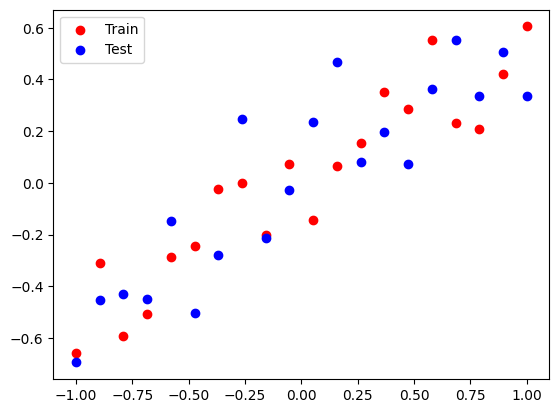

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.legend()
plt.show()

##Regression model

In [ ]:
model_1 = Sequential()
model_1.add(Dense(128,activation='relu',input_dim=1))
model_1.add(Dense(128,activation='relu'))
model_1.add(Dense(1,activation='linear'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_1.compile(loss='mean_squared_error',optimizer='adam',metrics=['mse'])

In [ ]:
history = model_1.fit(X_train,y_train,epochs=1000,
                      validation_data=(X_test,y_test),
                      verbose=0)

In [ ]:
model_1.evaluate(X_train,y_train)
model_1.evaluate(X_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0099 - mse: 0.0099
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0367 - mse: 0.0367


[0.036661311984062195, 0.036661311984062195]

In [ ]:
y_pred = model_1.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


(-1.5, 1.5)

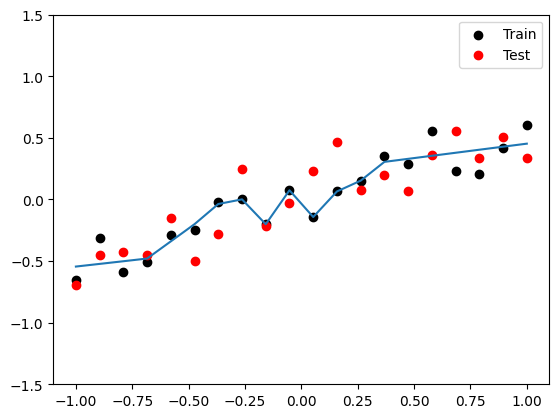

In [ ]:
plt.figure()
plt.scatter(X_train,y_train,c='black',label='Train')
plt.scatter(X_test,y_test,c='red',label='Test')
plt.plot(X_test,y_pred)
plt.legend()
plt.ylim((-1.5,1.5))

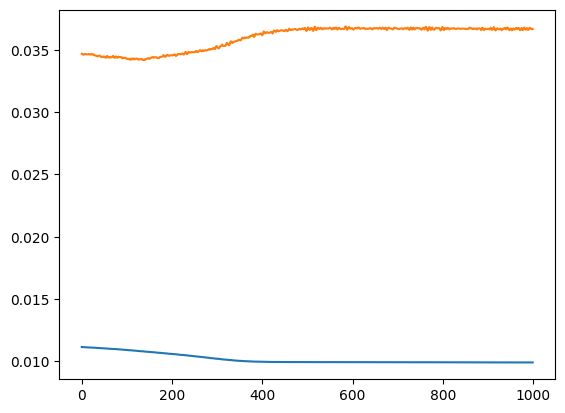

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
#a huge gap on train loss and validation loss shows overfitting

##Dropout model

In [ ]:
model_2 = Sequential()

model_2.add(Dense(128,activation='relu',input_dim=1))
model_2.add(Dropout(0.2))
model_2.add(Dense(128,activation='relu'))
model_2.add(Dropout(0.2))
model_2.add(Dense(1,activation='linear'))

In [ ]:
model_2.compile(loss='mse',optimizer='adam',metrics = ['mse'])

In [ ]:
history = model_2.fit(X_train,y_train,epochs=1000,validation_data=(X_test,y_test),verbose=False)

In [ ]:
model_2.evaluate(X_train,y_train)
model_2.evaluate(X_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0113 - mse: 0.0113
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0354 - mse: 0.0354


[0.03539913147687912, 0.03539913147687912]

In [ ]:
y_pred = model_2.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


(-1.5, 1.5)

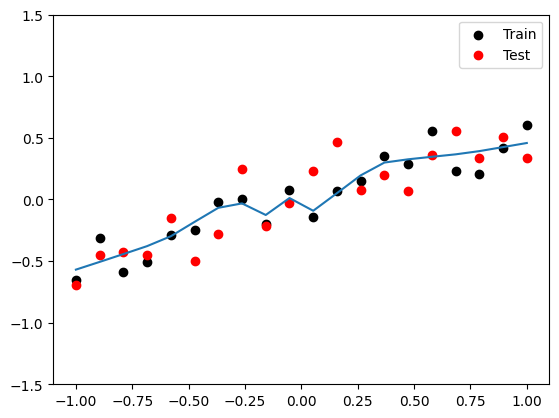

In [ ]:
plt.figure()
plt.scatter(X_train,y_train,c='black',label='Train')
plt.scatter(X_test,y_test,c='red',label='Test')
plt.plot(X_test,y_pred)
plt.legend()
plt.ylim((-1.5,1.5))

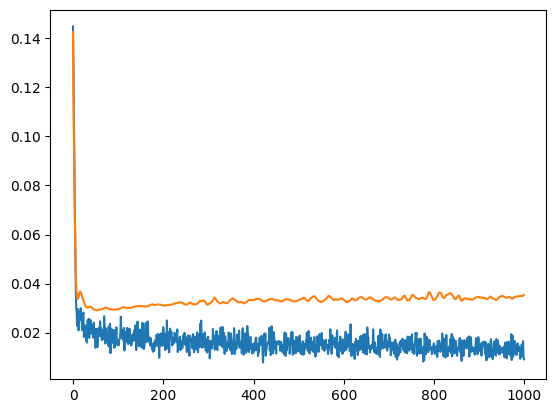

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [ ]:
model_3 = Sequential()

model_3.add(Dense(128,activation='relu',input_dim = 1))
model_3.add(Dropout(0.5))
model_3.add(Dense(128,activation='relu'))
model_3.add(Dropout(0.5))
model_3.add(Dense(1,activation='linear'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_3.compile(loss='mse',optimizer='adam',metrics=['mse'])

In [ ]:
history = model_3.fit(X_train,y_train,epochs=1000,validation_data=(X_test,y_test),verbose=False)

In [ ]:
y_pred  = model_3.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


(-1.5, 1.5)

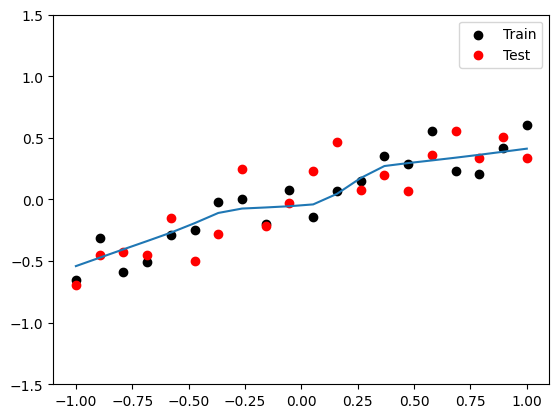

In [ ]:
plt.figure()
plt.scatter(X_train,y_train,c='black',label='Train')
plt.scatter(X_test,y_test,c='red',label='Test')
plt.plot(X_test,y_pred)
plt.legend()
plt.ylim((-1.5,1.5))

In [ ]:
model_3.evaluate(X_train,y_train)
model_3.evaluate(X_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0151 - mse: 0.0151
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0344 - mse: 0.0344


[0.03435886651277542, 0.03435886651277542]

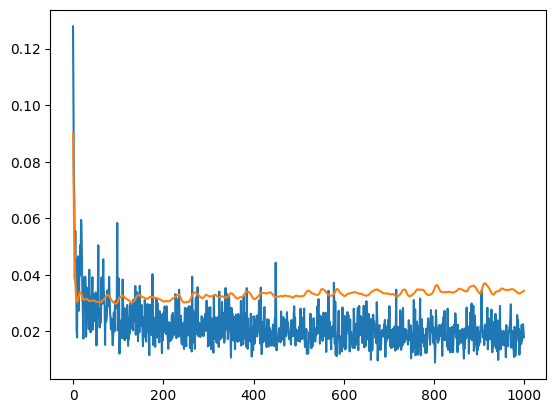

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])